In [1]:
import pandas as pd
import numpy as np

In [2]:
# load csv files
customers = pd.read_csv("customers_dataset.csv")
orders = pd.read_csv("orders_dataset.csv")
order_items = pd.read_csv("order_items_dataset.csv")
order_reviews = pd.read_csv("order_reviews_dataset.csv")
sellers = pd.read_csv("sellers_dataset.csv")

**Columns that we need**
<table style="border-collapse: collapse;">
<tr>
<td width="50%" valign="top" style="border: none;">

**Orders**
1. order_id
2. customer_id
3. order_purchase_timestamp
4. order_delivered_customer_date
5. order_estimated_delivery_date
6. order_delivered_carrier_date

**Customers**
1. customer_state
2. customer_city

</td>

<td width="50%" valign="top" style="border: none;">

**Sellers**
1. seller_state
2. seller_city

**Reviews**
1. review_score

**Order Items**
1. seller_id
2. price
3. freight_value

</td>
</tr>
</table>

In [3]:
#convert date columns
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

In [4]:
master = orders[[
        "order_id",
        "customer_id",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "order_delivered_carrier_date"]
].merge(
    customers[["customer_id", "customer_state", "customer_city"]],
    on="customer_id",
    how="left"
)
master = master.merge(
    order_reviews[["order_id", "review_score"]],
    on="order_id",
    how="left"
)
master = master.merge(
    order_items[["order_id", "seller_id", "price", "freight_value"]],
    on="order_id",
    how="left"
)
master = master.merge(
    sellers[["seller_id", "seller_state", "seller_city"]],
    on="seller_id",
    how="left"
)
print(master.shape)

(114092, 14)


In [5]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114092 entries, 0 to 114091
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       114092 non-null  object        
 1   customer_id                    114092 non-null  object        
 2   order_purchase_timestamp       114092 non-null  datetime64[ns]
 3   order_delivered_customer_date  110839 non-null  datetime64[ns]
 4   order_estimated_delivery_date  114092 non-null  datetime64[ns]
 5   order_delivered_carrier_date   112112 non-null  datetime64[ns]
 6   customer_state                 114092 non-null  object        
 7   customer_city                  114092 non-null  object        
 8   review_score                   113131 non-null  float64       
 9   seller_id                      113314 non-null  object        
 10  price                          113314 non-null  float64       
 11  

In [6]:
# Keeping only delivered orders for time-based metrics
delivered = master[master["order_delivered_customer_date"].notna()].copy()

# Core metrics
delivered["delivery_days"] = (
    delivered["order_delivered_customer_date"] - delivered["order_purchase_timestamp"]
).dt.days

delivered["delay_days"] = (
    delivered["order_delivered_customer_date"] - delivered["order_estimated_delivery_date"]
).dt.days  # positive = late, negative = early

delivered["is_late"] = delivered["delay_days"] > 0


In [7]:
delivered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110839 entries, 0 to 114091
Data columns (total 17 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110839 non-null  object        
 1   customer_id                    110839 non-null  object        
 2   order_purchase_timestamp       110839 non-null  datetime64[ns]
 3   order_delivered_customer_date  110839 non-null  datetime64[ns]
 4   order_estimated_delivery_date  110839 non-null  datetime64[ns]
 5   order_delivered_carrier_date   110838 non-null  datetime64[ns]
 6   customer_state                 110839 non-null  object        
 7   customer_city                  110839 non-null  object        
 8   review_score                   110012 non-null  float64       
 9   seller_id                      110839 non-null  object        
 10  price                          110839 non-null  float64       
 11  freig

In [8]:
# removeing order id duplicates to not double count delay orders
dup_count = delivered.duplicated(subset="order_id").sum()
print(f"Duplicate order_id rows: {dup_count}")
print(f"Total rows before dedup: {len(delivered)}")
print(f"Unique orders: {delivered['order_id'].nunique()}")

Duplicate order_id rows: 14363
Total rows before dedup: 110839
Unique orders: 96476


In [9]:
delivered_order_level = delivered.drop_duplicates(subset="order_id")

In [10]:
delivered_order_level.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96476 entries, 0 to 114091
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96476 non-null  object        
 1   customer_id                    96476 non-null  object        
 2   order_purchase_timestamp       96476 non-null  datetime64[ns]
 3   order_delivered_customer_date  96476 non-null  datetime64[ns]
 4   order_estimated_delivery_date  96476 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96475 non-null  datetime64[ns]
 6   customer_state                 96476 non-null  object        
 7   customer_city                  96476 non-null  object        
 8   review_score                   95830 non-null  float64       
 9   seller_id                      96476 non-null  object        
 10  price                          96476 non-null  float64       
 11  freight_value      

**Ques1. Do certain regions experience systematically worse delivery performance and satisfaction?**

In [11]:
regional = delivered_order_level.groupby("customer_state").agg(
    orders=("order_id", "count"),
    avg_delivery_days=("delivery_days", "mean"),
    pct_late=("is_late", "mean"), # % late
    avg_review_score=("review_score", "mean"),
    avg_delay_days=("delay_days", "mean")
).sort_values("pct_late", ascending=False)

regional["pct_late"] = (regional["pct_late"] * 100).round(1)
regional.round(2)

,orders,avg_delivery_days,pct_late,avg_review_score,avg_delay_days
customer_state,,,,,
AL,397,24.04,21.4,3.86,-8.71
MA,717,21.12,17.4,3.83,-9.57
SE,335,21.03,15.2,3.91,-10.02
PI,476,18.99,13.9,3.99,-11.31
CE,1279,20.82,13.8,3.94,-10.80
RR,41,28.98,12.2,3.90,-17.29
BA,3256,18.87,12.2,3.93,-10.79
RJ,12353,14.85,12.1,3.96,-11.77
PA,946,23.32,11.2,3.91,-14.07


In [12]:
# Filter to statistically reliable states first
MIN_ORDERS = 100
regional_reliable = regional[regional["orders"] >= MIN_ORDERS].copy()

print(f"Kept {len(regional_reliable)} out of {len(regional)} states after filtering (orders >= {MIN_ORDERS})")
print("Dropped states:", regional[regional["orders"] < MIN_ORDERS].index.tolist())


# Sorting by pct_late and separately by avg_review_score
worst_by_late = regional_reliable.sort_values("pct_late", ascending=False)
print("\n--- Worst states by % late ---")
print(worst_by_late[["orders", "pct_late", "avg_review_score"]].head(10))

worst_by_review = regional_reliable.sort_values("avg_review_score", ascending=True)
print("\n--- Worst states by avg review score ---")
print(worst_by_review[["orders", "pct_late", "avg_review_score"]].head(10))

Kept 24 out of 27 states after filtering (orders >= 100)
Dropped states: ['RR', 'AC', 'AP']

--- Worst states by % late ---
                orders  pct_late  avg_review_score
customer_state                                    
AL                 397      21.4          3.857868
MA                 717      17.4          3.832865
SE                 335      15.2          3.907186
PI                 476      13.9          3.993631
CE                1279      13.8          3.944226
BA                3256      12.2          3.930629
RJ               12353      12.1          3.964221
PA                 946      11.2          3.909968
ES                1995      10.7          4.080244
PB                 517      10.4          4.076172

--- Worst states by avg review score ---
                orders  pct_late  avg_review_score
customer_state                                    
MA                 717      17.4          3.832865
AL                 397      21.4          3.857868
SE                

In [15]:
regional_reliable.to_csv("regional_data.csv")

from google.colab import files
files.download("regional_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

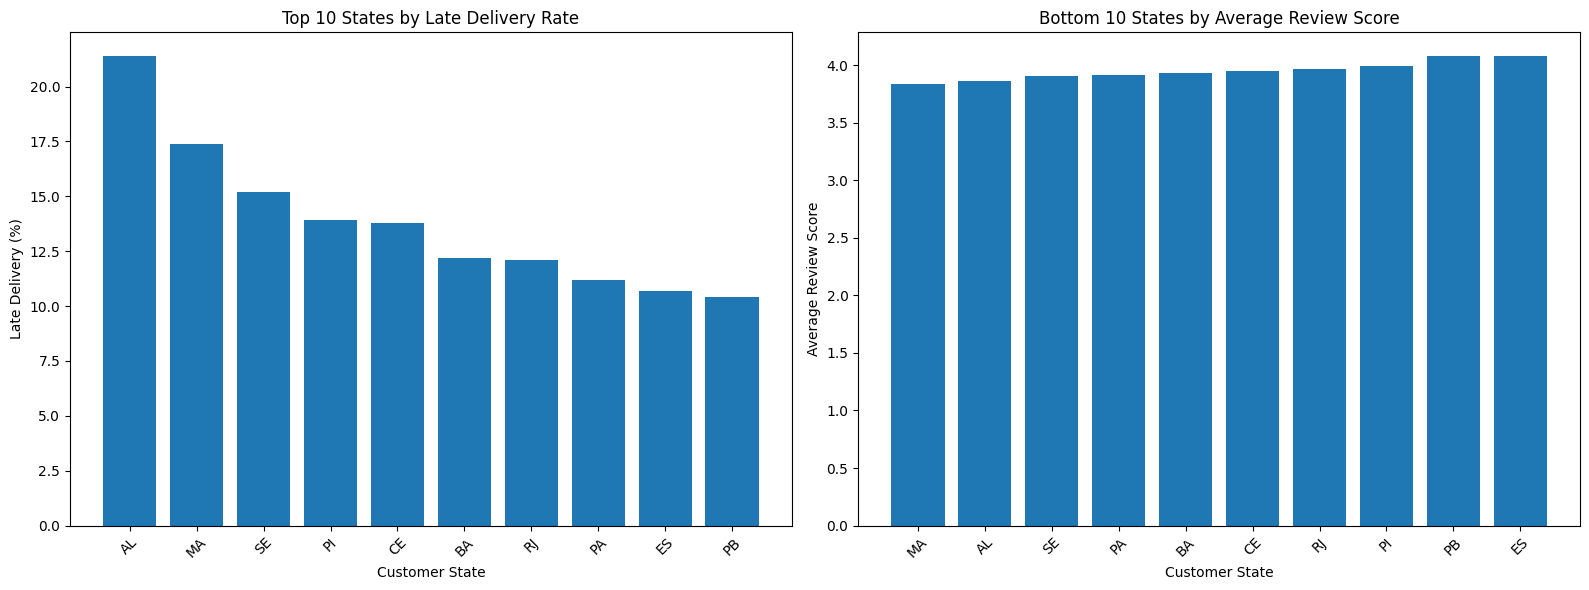

In [22]:
import matplotlib.pyplot as plt

# Top 10 states by late delivery
late_data = regional_reliable.sort_values(
    "pct_late", ascending=False
).head(10)

# Bottom 10 states by review score
review_data = regional_reliable.sort_values(
    "avg_review_score", ascending=True
).head(10)


# Graphs

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Late Delivery
axes[0].bar(
    late_data.index,
    late_data["pct_late"]
)

axes[0].set_xlabel("Customer State")
axes[0].set_ylabel("Late Delivery (%)")
axes[0].set_title("Top 10 States by Late Delivery Rate")
axes[0].tick_params(axis="x", rotation=45)

#Review Score
axes[1].bar(
    review_data.index,
    review_data["avg_review_score"]
)

axes[1].set_xlabel("Customer State")
axes[1].set_ylabel("Average Review Score")
axes[1].set_title("Bottom 10 States by Average Review Score")
axes[1].tick_params(axis="x", rotation=45)


plt.tight_layout()
plt.show()

**Ques2. Which seller-state → customer-state routes perform worst?**

In [13]:
routes = delivered.groupby(["seller_state", "customer_state"]).agg(
    orders=("order_id", "nunique"),
    avg_delivery_days=("delivery_days", "mean"),
    pct_late=("is_late", "mean"),
    avg_review_score=("review_score", "mean"),
    avg_delay_days=("delay_days", "mean")
).reset_index()

routes["pct_late"] = (routes["pct_late"] * 100).round(1)

# filter for statistical reliability
routes_reliable = routes[routes["orders"] >= 30].sort_values("avg_delay_days", ascending=False)
routes_reliable.head(20)

,seller_state,customer_state,orders,avg_delivery_days,pct_late,avg_review_score,avg_delay_days
254,PR,AL,36,30.627907,32.6,3.441860,-4.325581
285,RJ,CE,54,25.535714,23.2,3.553571,-5.125000
56,DF,DF,50,5.622951,8.2,4.311475,-7.573770
386,SP,AL,256,24.079422,22.7,3.683636,-8.256318
102,GO,GO,31,4.948718,0.0,4.538462,-9.179487
168,MG,SE,36,24.585366,12.2,4.358974,-9.365854
409,SP,SE,208,20.848101,18.1,3.797468,-9.375527
7,BA,BA,66,10.662162,8.1,4.243243,-9.418919
142,MA,SP,124,15.876923,21.5,3.920635,-9.561538
392,SP,ES,1467,15.263061,12.1,3.983831,-9.625691


In [16]:
routes_reliable.to_csv("routes_data.csv")

from google.colab import files
files.download("routes_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

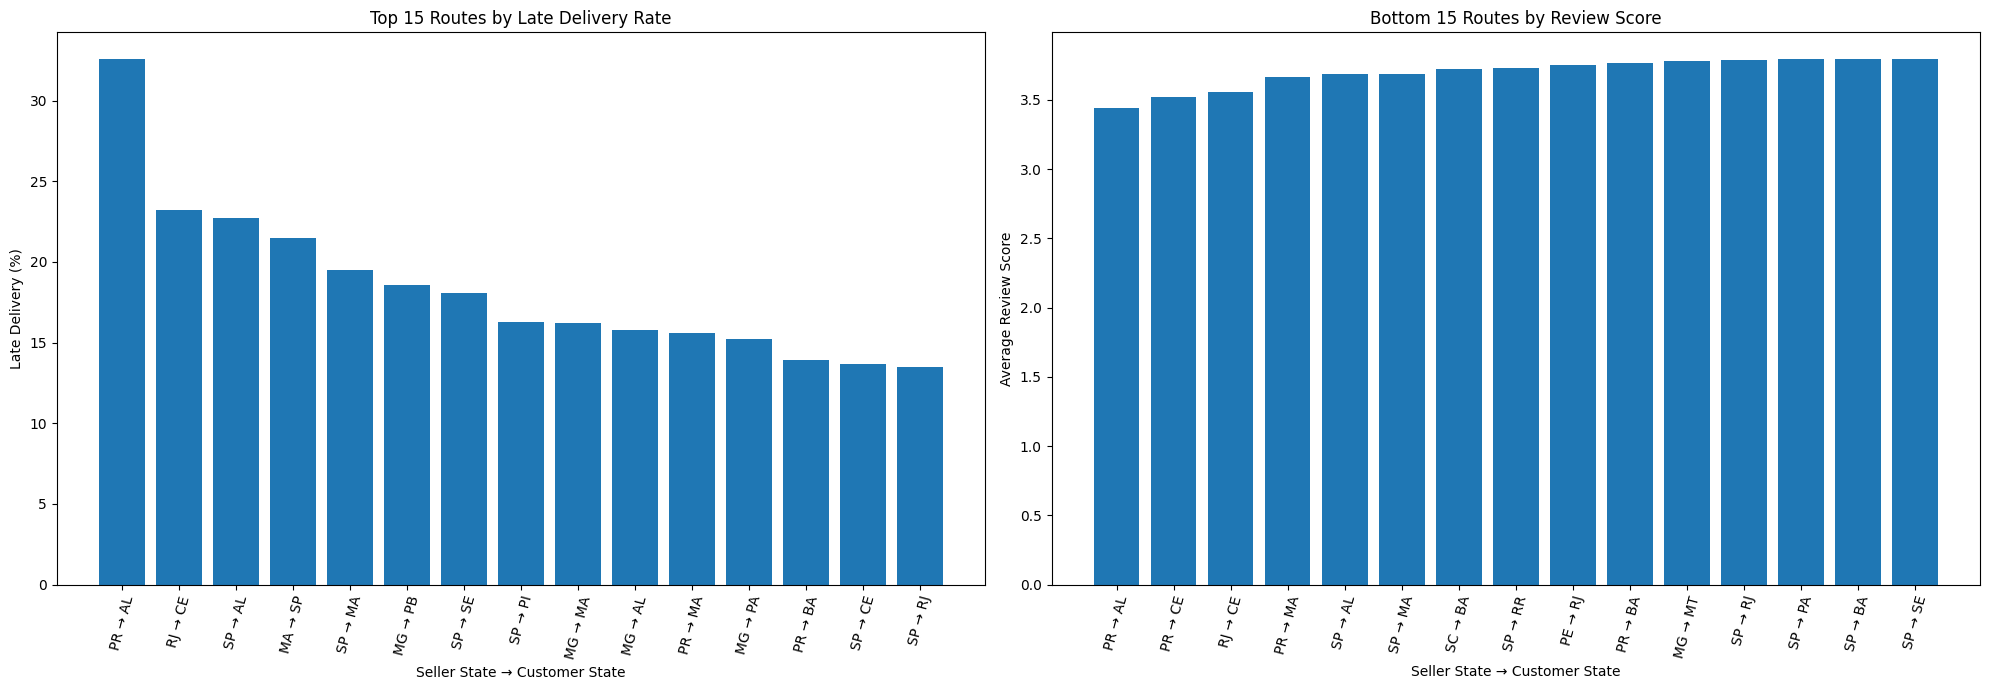

In [21]:
# Top 15 routes by late delivery
late_routes = routes_reliable.sort_values(
    "pct_late", ascending=False
).head(15).copy()

# Bottom 15 routes by review score
review_routes = routes_reliable.sort_values(
    "avg_review_score", ascending=True
).head(15).copy()


# Create route labels
late_routes["route"] = (
    late_routes["seller_state"]
    + " → "
    + late_routes["customer_state"]
)

review_routes["route"] = (
    review_routes["seller_state"]
    + " → "
    + review_routes["customer_state"]
)


# Graphs
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

#Late Delivery
axes[0].bar(
    late_routes["route"],
    late_routes["pct_late"]
)

axes[0].set_xlabel("Seller State → Customer State")
axes[0].set_ylabel("Late Delivery (%)")
axes[0].set_title("Top 15 Routes by Late Delivery Rate")
axes[0].tick_params(axis="x", rotation=75)


#Review Score
axes[1].bar(
    review_routes["route"],
    review_routes["avg_review_score"]
)

axes[1].set_xlabel("Seller State → Customer State")
axes[1].set_ylabel("Average Review Score")
axes[1].set_title("Bottom 15 Routes by Review Score")
axes[1].tick_params(axis="x", rotation=75)


plt.tight_layout()
plt.show()